# General Analisis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Configuración visual para gráficos estilo "publicación académica"
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "font.family": "serif"
})

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


In [2]:
# Carga directa desde el archivo generado por el benchmark
csv_filename = "exp_aleatory_fixed_2_8_5_2_1000/benchmark_granular_workflow.csv"

try:
    df = pd.read_csv(csv_filename)
    print(f"✅ Archivo '{csv_filename}' cargado exitosamente.")
    print(f"📊 Total de registros analizados: {len(df)}")
    
    # Separar los perfiles en Python y C++ para análisis específicos
    df_py = df[df['perfil'].isin(['seq', 'par', 'weights'])].copy()
    df_cpp = df[df['perfil'].str.startswith('cpp_')].copy()
    
    # Mostrar un resumen de los datos cargados
    display(df.head())
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{csv_filename}'.")
    print("Asegúrate de que el notebook esté en la misma carpeta que el CSV o ajusta la ruta.")

✅ Archivo 'exp_aleatory_fixed_2_8_5_2_1000/benchmark_granular_workflow.csv' cargado exitosamente.
📊 Total de registros analizados: 6000


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,8,seq,0.491197,0.000885,0.000835,0.492917,180.286133,7.759766,11.403320,180.286133,17,21,1
1,1,8,par,0.275924,0.028838,0.149072,0.453834,539.638672,47.037109,46.216797,539.638672,17,21,1
2,1,8,weights,0.255673,0.030166,0.151996,0.437834,170.463867,40.589844,44.548828,170.463867,17,21,1
3,1,8,cpp_seq,0.005461,0.000063,0.000074,0.005598,0.000000,0.000000,0.000000,0.000000,17,21,1
4,1,8,cpp_par,0.003148,0.000028,0.000070,0.003247,0.000000,0.000000,0.000000,0.000000,17,21,1


In [3]:
# Verificamos que para cada 'sample', el número de atractores, pares y campos sea idéntico en todos los perfiles
integrity_check = df.groupby('sample')[['n_attractors', 'n_pairs', 'n_fields']].nunique()

is_consistent = (integrity_check == 1).all().all()

if is_consistent:
    print("✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.")
else:
    print("❌ ADVERTENCIA: Hay discrepancias en los resultados topológicos entre los perfiles.")
    display(integrity_check[integrity_check > 1].dropna())

✅ INTEGRIDAD CONFIRMADA: Todos los perfiles resolvieron la misma topología con idénticos resultados.


In [4]:
# Cell 11: Speedup and Average Execution Time Analysis (Python vs C++)
import pandas as pd

# Calculate average execution times for each profile (robust against multiple samples)
t_py_seq = df.loc[df['perfil'] == 'seq', 'total_t'].mean()
t_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'total_t'].mean()

t_py_par = df.loc[df['perfil'] == 'par', 'total_t'].mean()
t_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'total_t'].mean()

# In Python the advanced parallel profile is 'weights', in C++ it is 'cpp_adv'
t_py_adv = df.loc[df['perfil'] == 'weights', 'total_t'].mean()
t_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'total_t'].mean()

# Speedup calculations (avoiding division by zero if any data is missing)
speedup_seq = (t_py_seq / t_cpp_seq) if t_cpp_seq > 0 else 0
speedup_par = (t_py_par / t_cpp_par) if t_cpp_par > 0 else 0
speedup_adv = (t_py_adv / t_cpp_adv) if t_cpp_adv > 0 else 0

print("=== 🚀 SPEEDUP ANALYSIS (PYTHON VS C++) ===")

print("\n--- 1. Sequential Comparison (Single Thread) ---")
print(f"⏱️ Python 'seq':     {t_py_seq:.6f} s")
print(f"⏱️ C++ 'cpp_seq':    {t_cpp_seq:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_seq:.2f}x faster")

print("\n--- 2. Parallel Comparison (Standard) ---")
print(f"⏱️ Python 'par':     {t_py_par:.6f} s")
print(f"⏱️ C++ 'cpp_par':    {t_cpp_par:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_par:.2f}x faster")

print(f"\n--- 3. Advanced Comparison (CBN-specific) ---")
print(f"⏱️ Python 'weights':  {t_py_adv:.6f} s")
print(f"⏱️ C++ 'cpp_adv':     {t_cpp_adv:.6f} s")
print(f"🔥 Speedup:          C++ is {speedup_adv:.2f}x faster")

=== 🚀 SPEEDUP ANALYSIS (PYTHON VS C++) ===

--- 1. Sequential Comparison (Single Thread) ---
⏱️ Python 'seq':     1.019148 s
⏱️ C++ 'cpp_seq':    0.013757 s
🔥 Speedup:          C++ is 74.08x faster

--- 2. Parallel Comparison (Standard) ---
⏱️ Python 'par':     0.661149 s
⏱️ C++ 'cpp_par':    0.012089 s
🔥 Speedup:          C++ is 54.69x faster

--- 3. Advanced Comparison (CBN-specific) ---
⏱️ Python 'weights':  0.640384 s
⏱️ C++ 'cpp_adv':     0.011767 s
🔥 Speedup:          C++ is 54.42x faster


In [5]:
# Cell 12: Generate LaTeX Table Code for the Paper
latex_table_code = f"""
\\begin{{table}}[htbp]
    \\centering
    \\caption{{Performance execution time comparison and speedup between Python and C++ implementations.}}
    \\label{{tab:cbn_performance_speedup}}
    \\begin{{tabular}}{{lrrr}}
        \\hline
        \\textbf{{Execution Strategy}} & \\textbf{{Python (s)}} & \\textbf{{C++ (s)}} & \\textbf{{Speedup}} \\\\ \\hline
        Sequential & {t_py_seq:.4f} & {t_cpp_seq:.4f} & \\textbf{{{speedup_seq:.1f}×}} \\\\
        Parallel   & {t_py_par:.4f} & {t_cpp_par:.4f} & \\textbf{{{speedup_par:.1f}×}} \\\\
        Advanced   & {t_py_adv:.4f} & {t_cpp_adv:.4f} & \\textbf{{{speedup_adv:.1f}×}} \\\\ \\hline
    \\end{{tabular}}
\\end{{table}}
"""

print("=== 📄 GENERATED LATEX TABLE CODE ===")
print(latex_table_code)

# Optional: Automatically save it to a .tex snippet file for LuaLaTeX `\\input{{}}` inclusion
with open("table_performance_speedup.tex", "w") as f:
    f.write(latex_table_code)
print("\n✅ Table successfully exported to 'table_performance_speedup.tex'!")

=== 📄 GENERATED LATEX TABLE CODE ===

\begin{table}[htbp]
    \centering
    \caption{Performance execution time comparison and speedup between Python and C++ implementations.}
    \label{tab:cbn_performance_speedup}
    \begin{tabular}{lrrr}
        \hline
        \textbf{Execution Strategy} & \textbf{Python (s)} & \textbf{C++ (s)} & \textbf{Speedup} \\ \hline
        Sequential & 1.0191 & 0.0138 & \textbf{74.1×} \\
        Parallel   & 0.6611 & 0.0121 & \textbf{54.7×} \\
        Advanced   & 0.6404 & 0.0118 & \textbf{54.4×} \\ \hline
    \end{tabular}
\end{table}


✅ Table successfully exported to 'table_performance_speedup.tex'!


In [6]:
# Cell 13: Memory Efficiency Analysis (Python vs C++)
import pandas as pd

# Calculate average total memory consumption (mem_total_kb) for each profile
mem_py_seq = df.loc[df['perfil'] == 'seq', 'mem_total_kb'].mean()
mem_cpp_seq = df.loc[df['perfil'] == 'cpp_seq', 'mem_total_kb'].mean()

mem_py_par = df.loc[df['perfil'] == 'par', 'mem_total_kb'].mean()
mem_cpp_par = df.loc[df['perfil'] == 'cpp_par', 'mem_total_kb'].mean()

mem_py_adv = df.loc[df['perfil'] == 'weights', 'mem_total_kb'].mean()
mem_cpp_adv = df.loc[df['perfil'] == 'cpp_adv', 'mem_total_kb'].mean()

# Overhead calculations. Handling division by zero for safety.
overhead_seq = (mem_py_seq / mem_cpp_seq) if mem_cpp_seq > 0 else float('inf')
overhead_par = (mem_py_par / mem_cpp_par) if mem_cpp_par > 0 else float('inf')
overhead_adv = (mem_py_adv / mem_cpp_adv) if mem_cpp_adv > 0 else float('inf')

print("=== 🧠 MEMORY EFFICIENCY ANALYSIS (PYTHON VS C++) ===")
print("Metric: Overhead Factor (How many times more memory Python requires)")

print("\n--- 1. Sequential Comparison (Single Thread) ---")
print(f"📦 Python 'seq':      {mem_py_seq:.2f} KB")
print(f"📦 C++ 'cpp_seq':     {mem_cpp_seq:.2f} KB")
if mem_cpp_seq > 0:
    print(f"📉 Overhead:        Python consumes {overhead_seq:.2f}x more memory")
else:
    print("📉 Overhead:        N/A (C++ reports 0 KB)")

print("\n--- 2. Parallel Comparison (Standard) ---")
print(f"📦 Python 'par':      {mem_py_par:.2f} KB")
print(f"📦 C++ 'cpp_par':     {mem_cpp_par:.2f} KB")
if mem_cpp_par > 0:
    print(f"📉 Overhead:        Python consumes {overhead_par:.2f}x more memory")

print("\n--- 3. Advanced Comparison (CBN-specific) ---")
print(f"📦 Python 'weights':  {mem_py_adv:.2f} KB")
print(f"📦 C++ 'cpp_adv':     {mem_cpp_adv:.2f} KB")
if mem_cpp_adv > 0:
    print(f"📉 Overhead:        Python consumes {overhead_adv:.2f}x more memory")

# Parallelism Memory Penalty Analysis
print("\n--- ⚠️ MEMORY PENALTY FOR MULTIPROCESSING ---")
penalidad_py = (mem_py_par / mem_py_seq) if mem_py_seq > 0 else 0
penalidad_cpp = (mem_cpp_par / mem_cpp_seq) if mem_cpp_seq > 0 else 0
print(f"When switching from Sequential to Parallel:")
print(f"🐍 Python inflates its memory by: {penalidad_py:.2f}x")
print(f"⚙️ C++ inflates its memory by:    {penalidad_cpp:.2f}x")

=== 🧠 MEMORY EFFICIENCY ANALYSIS (PYTHON VS C++) ===
Metric: Overhead Factor (How many times more memory Python requires)

--- 1. Sequential Comparison (Single Thread) ---
📦 Python 'seq':      255.65 KB
📦 C++ 'cpp_seq':     0.00 KB
📉 Overhead:        N/A (C++ reports 0 KB)

--- 2. Parallel Comparison (Standard) ---
📦 Python 'par':      470.99 KB
📦 C++ 'cpp_par':     0.00 KB

--- 3. Advanced Comparison (CBN-specific) ---
📦 Python 'weights':  362.34 KB
📦 C++ 'cpp_adv':     0.00 KB

--- ⚠️ MEMORY PENALTY FOR MULTIPROCESSING ---
When switching from Sequential to Parallel:
🐍 Python inflates its memory by: 1.84x
⚙️ C++ inflates its memory by:    0.00x


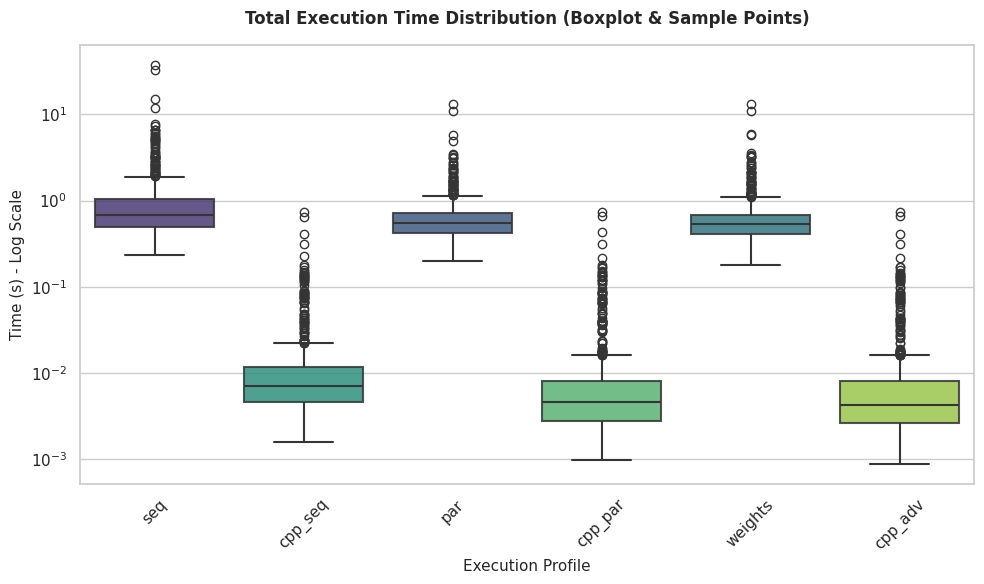

In [27]:
# Cell 7: Modernized Total Execution Time Distribution (Boxplot with Stripplot Overlay)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Ensure visual order: Python followed by C++ implementation for each strategy
profile_order = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

# Modern boxplot syntax (fixing palette/hue deprecation warning)
sns.boxplot(
    data=df, 
    x='perfil', 
    y='total_t', 
    order=profile_order, 
    hue='perfil',
    palette='viridis',
    legend=False,
    ax=ax,
    boxprops=dict(alpha=0.85),
    linewidth=1.5
)

ax.set_title('Total Execution Time Distribution (Boxplot & Sample Points)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Time (s) - Log Scale', fontsize=11)
ax.set_xlabel('Execution Profile', fontsize=11)
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# Vectorial export for the academic paper
plt.tight_layout()
plt.savefig("boxplot_execution_time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [8]:
# Cell 14: Generate LaTeX Memory Table Code for the Paper
latex_memory_table_code = f"""
\\begin{{table}}[htbp]
    \\centering
    \\caption{{Peak memory consumption (KB) and overhead factor comparison between Python and C++ implementations.}}
    \\label{{tab:cbn_memory_overhead}}
    \\begin{{tabular}}{{lrrr}}
        \\hline
        \\textbf{{Execution Strategy}} & \\textbf{{Python (KB)}} & \\textbf{{C++ (KB)}} & \\textbf{{Overhead}} \\\\ \\hline
        Sequential & {mem_py_seq:.2f} & {mem_cpp_seq:.2f} & \\textbf{{{overhead_seq:.1f}×}} \\\\
        Parallel   & {mem_py_par:.2f} & {mem_cpp_par:.2f} & \\textbf{{{overhead_par:.1f}×}} \\\\
        Advanced   & {mem_py_adv:.2f} & {mem_cpp_adv:.2f} & \\textbf{{{overhead_adv:.1f}×}} \\\\ \\hline
    \\end{{tabular}}
\\end{{table}}
"""

print("=== 📄 GENERATED LATEX MEMORY TABLE CODE ===")
print(latex_memory_table_code)

# Export snippet file for LuaLaTeX `\\input{{}}` inclusion
with open("table_memory_overhead.tex", "w") as f:
    f.write(latex_memory_table_code)
print("\n✅ Memory table successfully exported to 'table_memory_overhead.tex'!")

=== 📄 GENERATED LATEX MEMORY TABLE CODE ===

\begin{table}[htbp]
    \centering
    \caption{Peak memory consumption (KB) and overhead factor comparison between Python and C++ implementations.}
    \label{tab:cbn_memory_overhead}
    \begin{tabular}{lrrr}
        \hline
        \textbf{Execution Strategy} & \textbf{Python (KB)} & \textbf{C++ (KB)} & \textbf{Overhead} \\ \hline
        Sequential & 255.65 & 0.00 & \textbf{inf×} \\
        Parallel   & 470.99 & 0.00 & \textbf{inf×} \\
        Advanced   & 362.34 & 0.00 & \textbf{inf×} \\ \hline
    \end{tabular}
\end{table}


✅ Memory table successfully exported to 'table_memory_overhead.tex'!


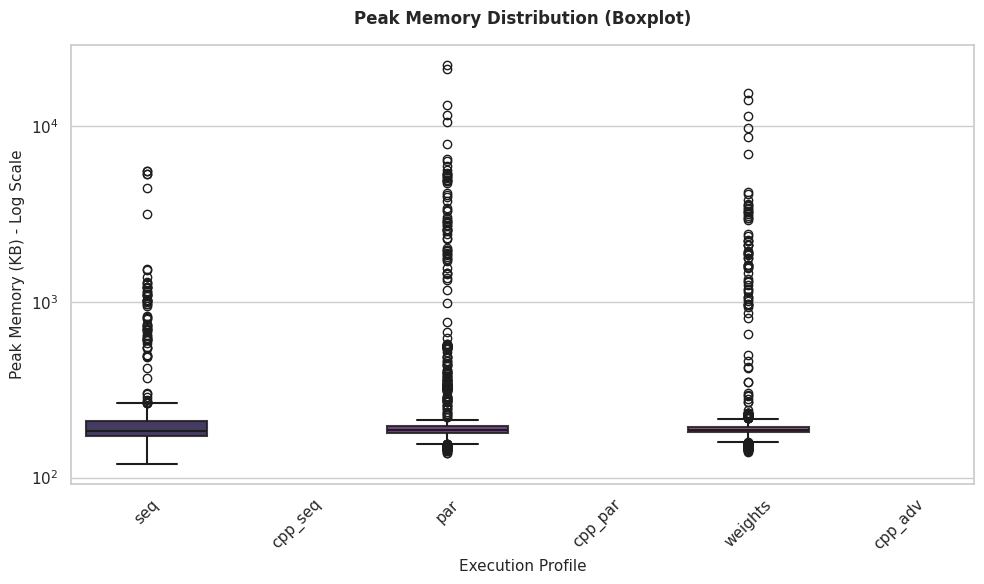

In [9]:
# Cell 8: Peak Memory Distribution (Python vs C++ Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Ensure visual order: Python (higher footprint) followed by C++ implementation for each strategy
profile_order = ['seq', 'cpp_seq', 'par', 'cpp_par', 'weights', 'cpp_adv']

fig, ax = plt.subplots(figsize=(10, 6))

# Modern boxplot syntax (fixing palette/hue deprecation warning)
sns.boxplot(
    data=df, 
    x='perfil', 
    y='mem_total_kb', 
    order=profile_order, 
    hue='perfil',
    palette='magma',
    legend=False,
    ax=ax,
    boxprops=dict(alpha=0.85),
    linewidth=1.5
)

ax.set_title('Peak Memory Distribution (Boxplot)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Peak Memory (KB) - Log Scale', fontsize=11)
ax.set_xlabel('Execution Profile', fontsize=11)
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

# Vectorial export for the academic paper
plt.tight_layout()
plt.savefig("boxplot_peak_memory.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Analisis by step

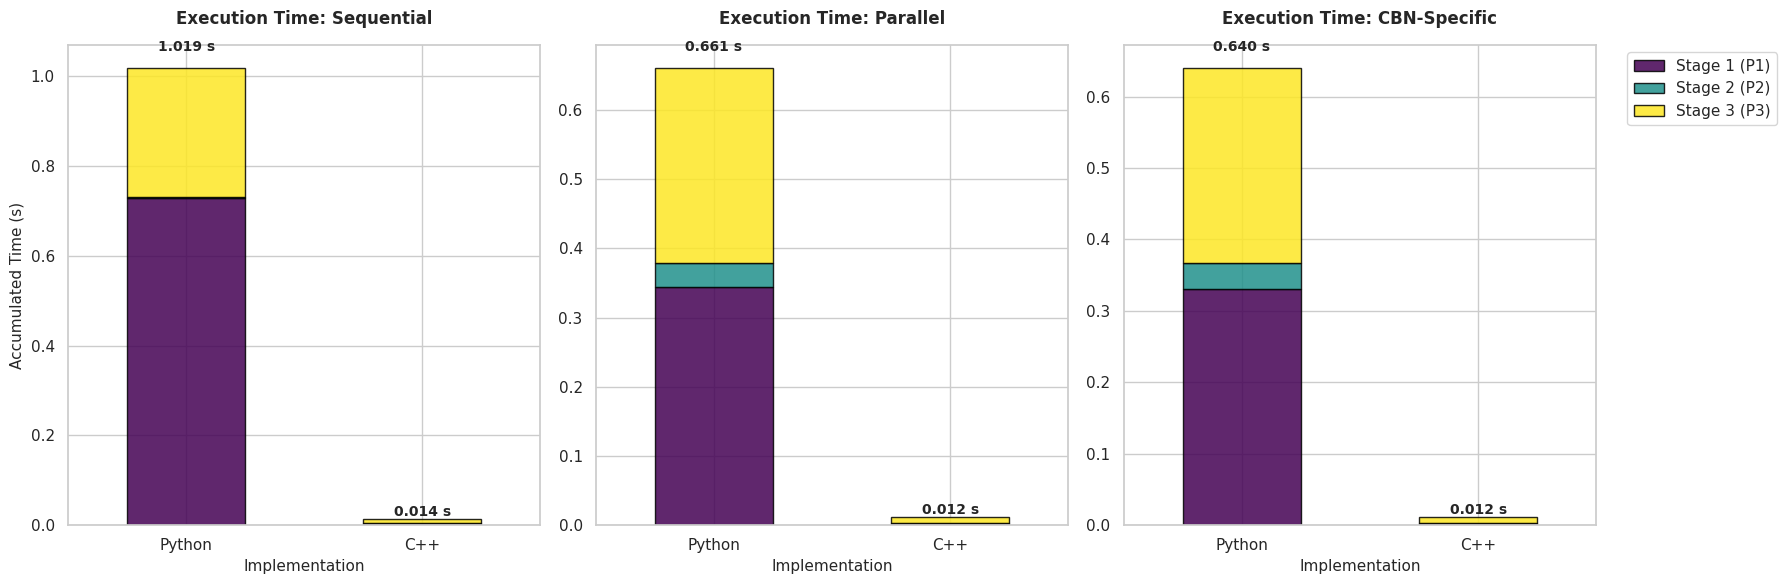

In [10]:
# Cell: Cumulative Stacked Execution Time Breakdown by Stage (Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Exact columns from your dataframe
time_cols = ['t_p1', 't_p2', 't_p3']

# Define exact comparative pairs (Python first, C++ second)
comparative_pairs = [
    ('Sequential', ['seq', 'cpp_seq']),
    ('Parallel', ['par', 'cpp_par']),
    ('CBN-Specific', ['weights', 'cpp_adv'])
]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (title, profiles) in enumerate(comparative_pairs):
    # Filter data for the current comparison round
    df_par = df[df['perfil'].isin(profiles)].copy()
    
    # Group by profile and average time stages
    df_mean = df_par.groupby('perfil')[time_cols].mean().reset_index()
    
    # Create language column to structure the chart clearly
    df_mean['Language'] = df_mean['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # SORT: Python first (left), then C++ (right)
    df_mean = df_mean.sort_values(by='Language', ascending=False).set_index('Language')
    
    # Plot stacked bars using 'crest' colormap for a professional academic look
    df_mean[time_cols].plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='black', alpha=0.85
    )
    
    axes[i].set_title(f"Execution Time: {title}", fontweight='bold', pad=15, fontsize=12)
    axes[i].set_xlabel("Implementation", fontsize=11)
    axes[i].tick_params(axis='x', rotation=0)
    
    if i == 0:
        axes[i].set_ylabel("Accumulated Time (s)", fontsize=11)
    else:
        axes[i].set_ylabel("")
        
    # Add precise total value label on top of each stacked bar
    for j, (idx, row) in enumerate(df_mean.iterrows()):
        total_stacked = row[time_cols].sum()
        axes[i].text(j, total_stacked + (total_stacked * 0.03), f"{total_stacked:.3f} s", 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Show legend only on the rightmost plot to avoid cluttering
    if i == 2:
        axes[i].legend(["Stage 1 (P1)", "Stage 2 (P2)", "Stage 3 (P3)"], 
                       loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True)
    else:
        axes[i].legend().remove()

# Adjust margins to prevent clipping upon export
plt.tight_layout()
plt.savefig("time_stacked_python_vs_cpp.pdf", format='pdf', bbox_inches='tight')
plt.show()

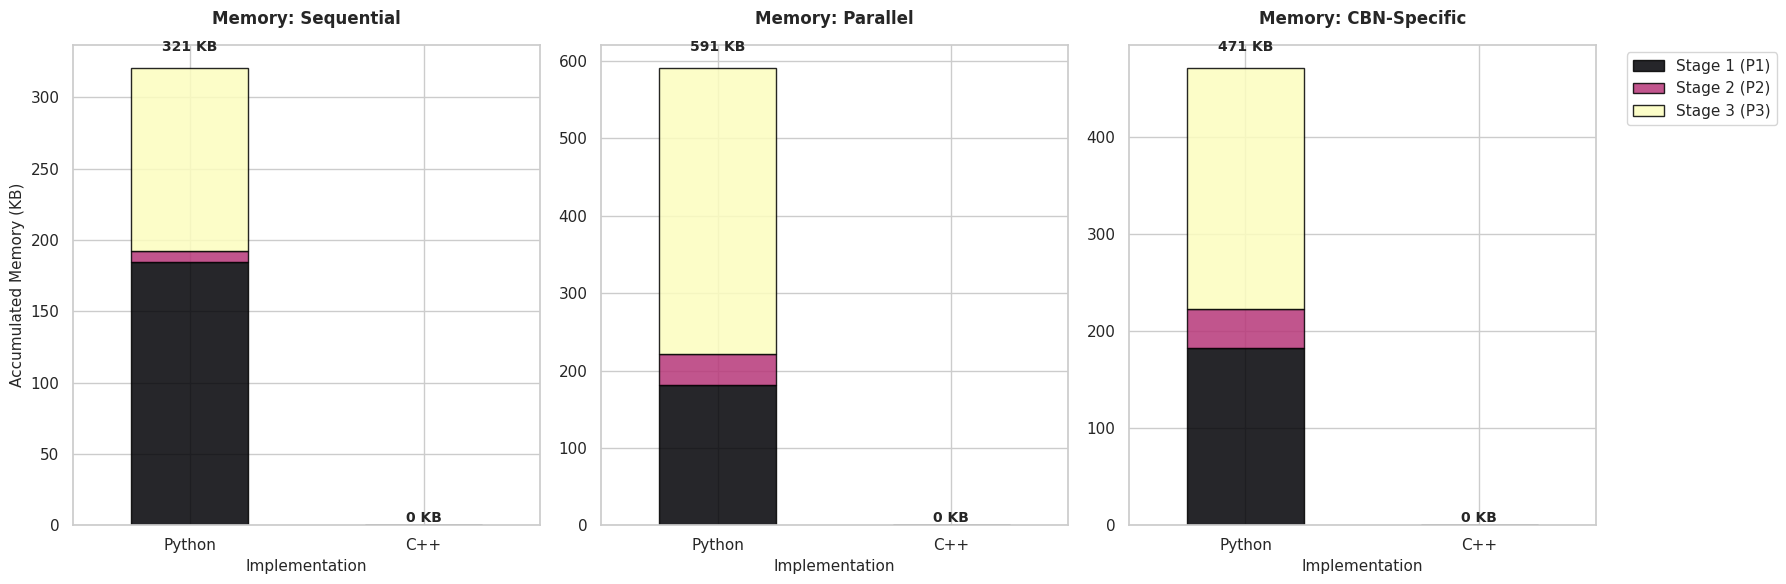

In [11]:
# Cell 6: Cumulative Stacked Memory Breakdown Comparison (Python vs C++)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Define exact comparative pairs (Python first, C++ second)
comparative_pairs = [
    ('Sequential', ['seq', 'cpp_seq']),
    ('Parallel', ['par', 'cpp_par']),
    ('CBN-Specific', ['weights', 'cpp_adv'])
]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (title, profiles) in enumerate(comparative_pairs):
    # Filter data for the current comparison round
    df_par = df[df['perfil'].isin(profiles)].copy()
    
    # Group by profile and average memory stages
    df_mean = df_par.groupby('perfil')[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].mean().reset_index()
    
    # Create language column to structure the chart clearly
    df_mean['Language'] = df_mean['perfil'].apply(
        lambda x: 'C++' if x.startswith('cpp_') else 'Python'
    )
    
    # SORT: Python first (left), then C++ (right)
    # ascending=False ensures 'Python' comes before 'C++' alphabetically
    df_mean = df_mean.sort_values(by='Language', ascending=False).set_index('Language')
    
    # Plot stacked bars using 'magma' colormap for high-contrast academic printing
    df_mean[['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb']].plot(
        kind='bar', stacked=True, ax=axes[i], colormap='magma', edgecolor='black', alpha=0.85
    )
    
    axes[i].set_title(f"Memory: {title}", fontweight='bold', pad=15, fontsize=12)
    axes[i].set_xlabel("Implementation", fontsize=11)
    axes[i].tick_params(axis='x', rotation=0)
    
    if i == 0:
        axes[i].set_ylabel("Accumulated Memory (KB)", fontsize=11)
    else:
        axes[i].set_ylabel("")
        
    # Add total value label on top of each stacked bar for precise reporting
    for j, (idx, row) in enumerate(df_mean.iterrows()):
        total_stacked = row['mem_p1_kb'] + row['mem_p2_kb'] + row['mem_p3_kb']
        axes[i].text(j, total_stacked + (total_stacked * 0.03), f"{total_stacked:.0f} KB", 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Show legend only on the rightmost plot to avoid cluttering the visual area
    if i == 2:
        axes[i].legend(["Stage 1 (P1)", "Stage 2 (P2)", "Stage 3 (P3)"], 
                       loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True)
    else:
        axes[i].legend().remove()

# Adjust margins to prevent text or legend clipping upon export
plt.tight_layout()
plt.savefig("memory_stacked_python_vs_cpp.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [12]:
# Celda 8: Análisis Estadístico Descriptivo

print("=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===")
# Agrupamos por perfil y calculamos métricas clave
time_stats = df.groupby('perfil')['total_t'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos de más lento a más rápido
time_stats = time_stats.sort_values(by='Media', ascending=False)
display(time_stats.style.format("{:.6f}", na_rep="-").background_gradient(cmap='Blues'))

print("\n=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===")
mem_stats = df.groupby('perfil')['mem_total_kb'].agg(
    Muestras='count',
    Media='mean',
    Desv_Estandar='std',
    Mediana='median',
    Minimo='min',
    Maximo='max'
)
# Ordenamos del que consume más memoria al que menos
mem_stats = mem_stats.sort_values(by='Media', ascending=False)
display(mem_stats.style.format("{:.2f}", na_rep="-").background_gradient(cmap='Reds'))

# Exportar las estadísticas descriptivas directamente a un archivo LaTeX para Overleaf
time_stats.to_latex("table_times_summary.tex", float_format="%.4f")
mem_stats.to_latex("table_memory_summary.tex", float_format="%.2f")

=== ⏱️ ANÁLISIS ESTADÍSTICO DE RENDIMIENTO (TIEMPO EN SEGUNDOS) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
seq,1000.000000,1.019148,1.837616,0.673164,0.235088,37.775655
par,1000.000000,0.661149,0.674755,0.546261,0.198028,13.245214
weights,1000.000000,0.640384,0.678736,0.533103,0.176155,13.093864
cpp_seq,1000.000000,0.013757,0.045947,0.006934,-0.682102,0.731799
cpp_par,1000.000000,0.012089,0.040721,0.004528,0.000974,0.728129
cpp_adv,1000.000000,0.011767,0.040187,0.004278,0.000877,0.729927



=== 🧠 ANÁLISIS ESTADÍSTICO DE HUELLA DE MEMORIA (ESPACIO EN KB) ===


,Muestras,Media,Desv_Estandar,Mediana,Minimo,Maximo
perfil,,,,,,
par,1000.00,470.99,1412.44,186.29,138.54,22397.51
weights,1000.00,362.34,995.61,187.29,139.99,15467.49
seq,1000.00,255.65,407.27,183.89,119.91,5547.14
cpp_adv,1000.00,0.00,0.00,0.00,0.00,0.00
cpp_par,1000.00,0.00,0.00,0.00,0.00,0.00
cpp_seq,1000.00,0.00,0.00,0.00,0.00,0.00


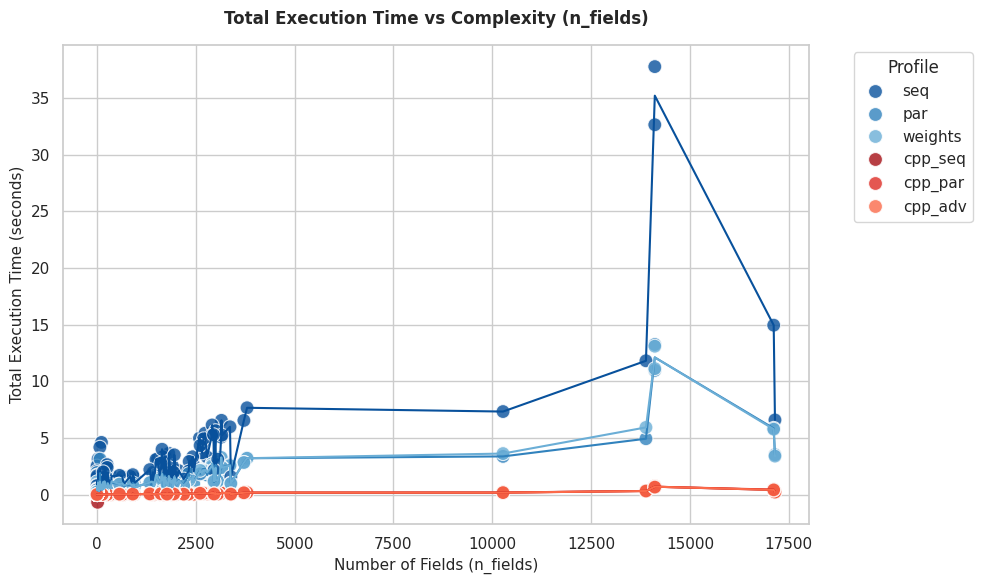

In [13]:
# Cell 10a: Complexity Relationship (n_fields) vs Total Time (total_t)
import matplotlib.pyplot as plt
import seaborn as sns

# Unified palette: Blues for Python, Reds for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=df, x='n_fields', y='total_t', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)

# Clean trend lines (errorbar=None avoids cluttered confidence intervals)
sns.lineplot(
    data=df, x='n_fields', y='total_t', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Total Execution Time vs Complexity (n_fields)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Total Execution Time (seconds)', fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=11)

# Clean sidebar legend
plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Vector export for LuaLaTeX
plt.tight_layout()
plt.savefig("complexity_vs_total_time.pdf", format='pdf', bbox_inches='tight')
plt.show()

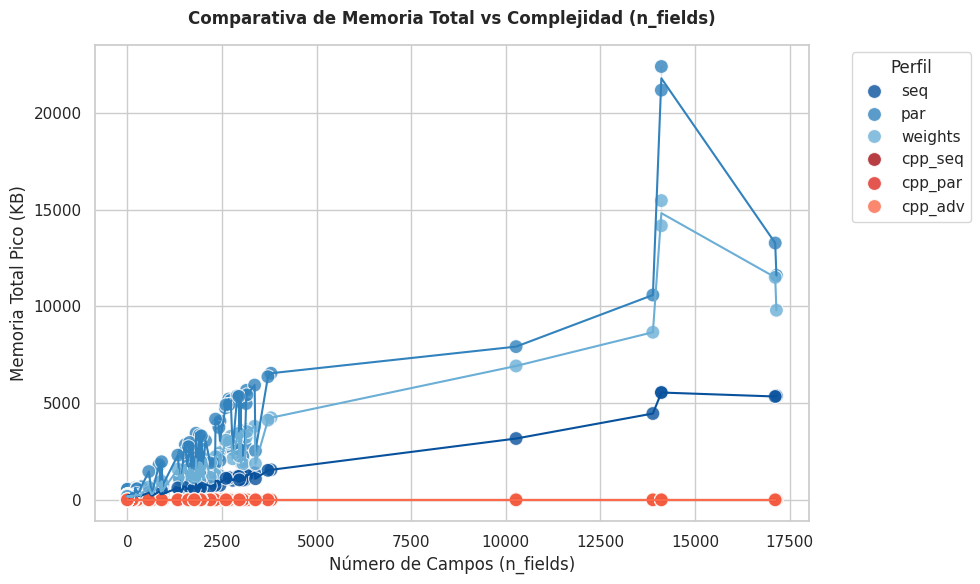

In [14]:
# Celda 10b: Relación de Complejidad (n_fields) vs Memoria Total (mem_total_kb)
import matplotlib.pyplot as plt
import seaborn as sns

paleta_perfiles = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, s=100, alpha=0.8, ax=ax)
sns.lineplot(data=df, x='n_fields', y='mem_total_kb', hue='perfil', palette=paleta_perfiles, legend=False, ax=ax)

ax.set_title('Comparativa de Memoria Total vs Complejidad (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Memoria Total Pico (KB)')
ax.set_xlabel('Número de Campos (n_fields)')

plt.legend(title='Perfil', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("complejidad_vs_memoria_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Especific Analisis Step 3

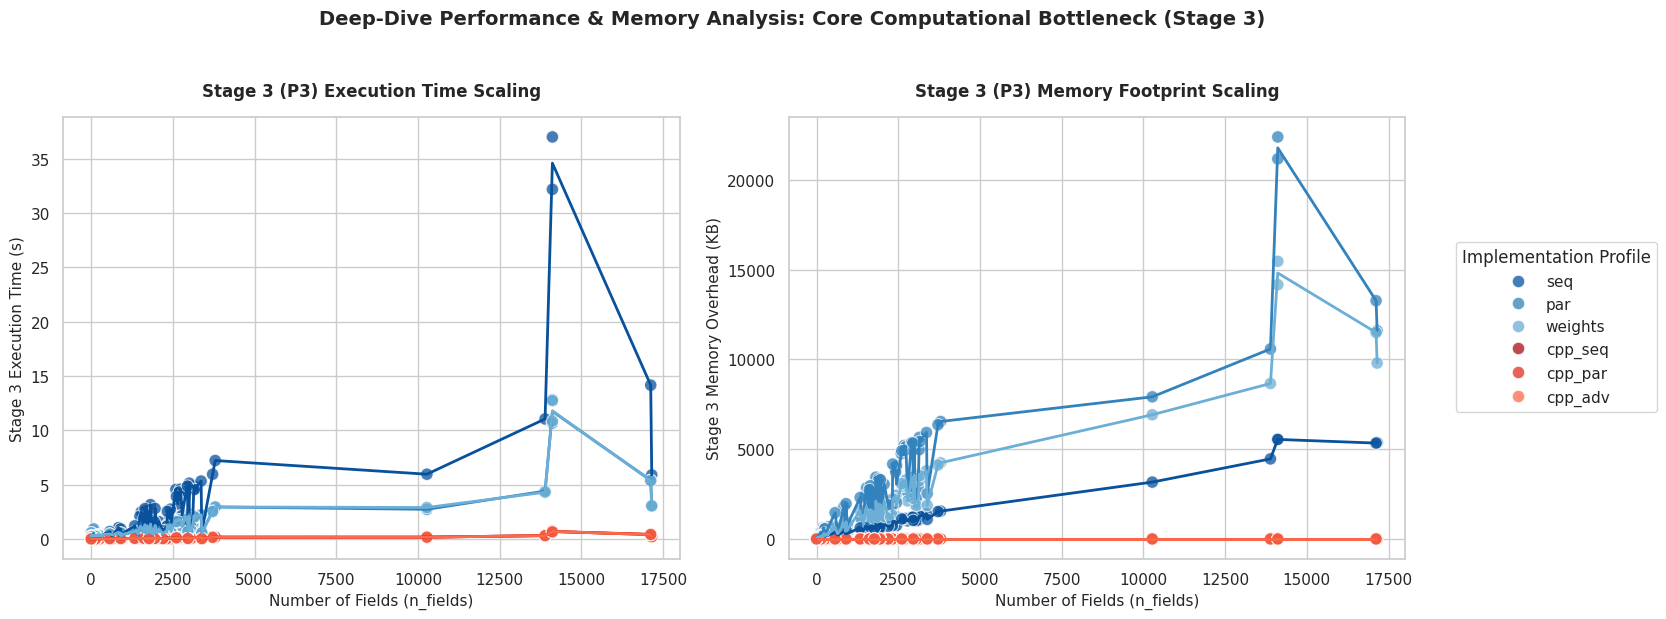

In [15]:
# Cell: Megaplot - Stage 3 (P3) Deep Dive: Time and Memory Scaling vs. Complexity
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean academic aesthetic
sns.set_theme(style="whitegrid")

# Unified custom palette: Blues for Python, Reds for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

# Create a figure with 2 subplots side-by-side (1 row, 2 columns) with adjusted width for the legend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Step 3 Execution Time vs n_fields ---
sns.scatterplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, s=80, alpha=0.75, ax=axes[0], legend=True
)
sns.lineplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, linewidth=2, ax=axes[0]
)
axes[0].set_title('Stage 3 (P3) Execution Time Scaling', fontweight='bold', pad=15, fontsize=12)
axes[0].set_xlabel('Number of Fields (n_fields)', fontsize=11)
axes[0].set_ylabel('Stage 3 Execution Time (s)', fontsize=11)

# --- Panel 2: Step 3 Memory Overhead vs n_fields ---
sns.scatterplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, s=80, alpha=0.75, ax=axes[1], legend=False
)
sns.lineplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, linewidth=2, ax=axes[1]
)
axes[1].set_title('Stage 3 (P3) Memory Footprint Scaling', fontweight='bold', pad=15, fontsize=12)
axes[1].set_xlabel('Number of Fields (n_fields)', fontsize=11)
axes[1].set_ylabel('Stage 3 Memory Overhead (KB)', fontsize=11)

# Extract handles and labels from the first axis to build a clean unified legend
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove() # Remove individual legend

# Position a professional unified legend on the right side
fig.legend(handles, labels, title='Implementation Profile', loc='center left', bbox_to_anchor=(0.91, 0.5), frameon=True)

# Main title for the entire megagraphics canvas
plt.suptitle('Deep-Dive Performance & Memory Analysis: Core Computational Bottleneck (Stage 3)', fontsize=14, fontweight='bold', y=1.03)

# Vector export for LaTeX / Overleaf with extra margin for the external legend
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig("megaplot_stage3_deep_dive.pdf", format='pdf', bbox_inches='tight')
plt.show()

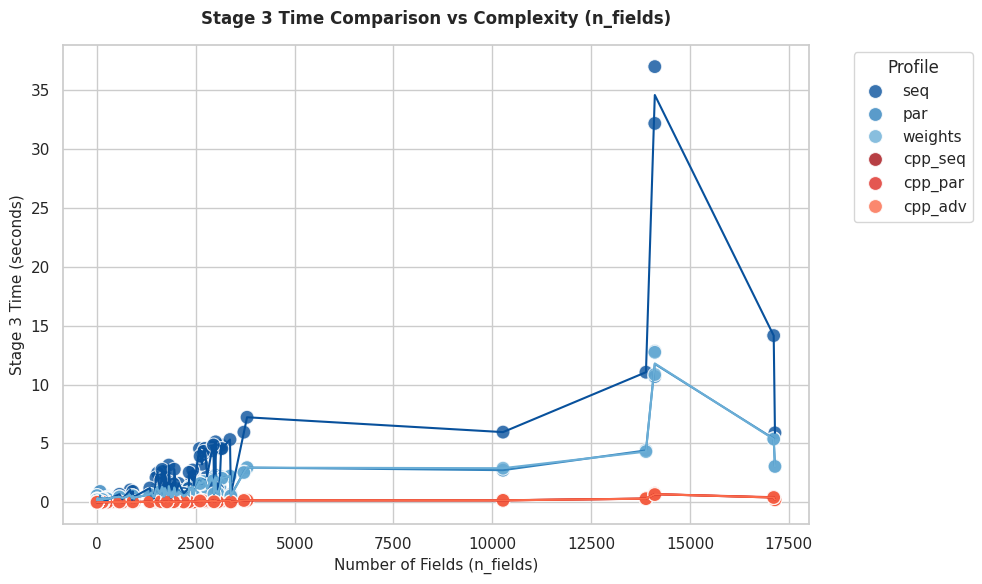

In [16]:
# Cell 9a: Complexity vs Time Relationship in Stage 3 (P3)
import matplotlib.pyplot as plt
import seaborn as sns

# Custom palette: Blues for Python, Reds/Oranges for C++
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot and trend lines
sns.scatterplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df, x='n_fields', y='t_p3', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Stage 3 Time Comparison vs Complexity (n_fields)', fontweight='bold', pad=15, fontsize=12)
ax.set_ylabel('Stage 3 Time (seconds)', fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=11)

# Logarithmic scale crucial to see the C++ trend without flattening
# ax.set_yscale('log') 

# Adjust legend outside the plot
plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("complexity_vs_time_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

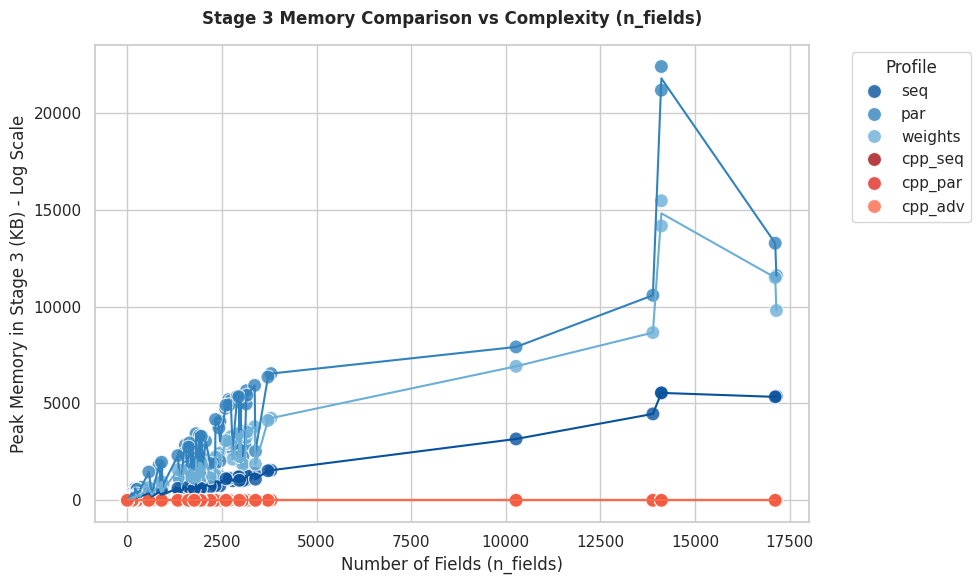


=== 📈 (PEARSON) CORRELATION WITH n_fields IN STAGE 3 ===

🐍 PYTHON:
  • Correlation n_fields vs Time P3:   0.7347
  • Correlation n_fields vs Memory P3: 0.8678

⚙️ C++:
  • Correlation n_fields vs Time P3:   0.8926
  • Correlation n_fields vs Memory P3: nan


/home/carlos/Documentos/proyectos/cbn_core/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/carlos/Documentos/proyectos/cbn_core/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [17]:
# Cell 9b: Complexity vs Memory Relationship in Stage 3 (P3) and Correlation
import matplotlib.pyplot as plt
import seaborn as sns

# We use the same palette to maintain visual consistency
profile_palette = {
    'seq': '#08519c', 'par': '#3182bd', 'weights': '#6baed6',     # Python
    'cpp_seq': '#a50f15', 'cpp_par': '#de2d26', 'cpp_adv': '#fb6a4a'  # C++
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, s=100, alpha=0.8, ax=ax
)
sns.lineplot(
    data=df, x='n_fields', y='mem_p3_kb', hue='perfil', 
    palette=profile_palette, legend=False, errorbar=None, ax=ax
)

ax.set_title('Stage 3 Memory Comparison vs Complexity (n_fields)', fontweight='bold', pad=15)
ax.set_ylabel('Peak Memory in Stage 3 (KB) - Log Scale')
ax.set_xlabel('Number of Fields (n_fields)')
#ax.set_yscale('log')

plt.legend(title='Profile', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("complexity_vs_memory_p3.pdf", format='pdf', bbox_inches='tight')
plt.show()

# --- CORRELATION ANALYSIS ---
print("\n=== 📈 (PEARSON) CORRELATION WITH n_fields IN STAGE 3 ===")

print("\n🐍 PYTHON:")
# Use the filtered Python DataFrame (df_py) to isolate metrics
if df_py['n_fields'].nunique() > 1:
    corr_py_t = df_py['n_fields'].corr(df_py['t_p3'])
    corr_py_m = df_py['n_fields'].corr(df_py['mem_p3_kb'])
    print(f"  • Correlation n_fields vs Time P3:   {corr_py_t:.4f}")
    print(f"  • Correlation n_fields vs Memory P3: {corr_py_m:.4f}")
else:
    print("  • Run the benchmark with multiple topologies to calculate correlation.")

print("\n⚙️ C++:")
# Use the filtered C++ DataFrame (df_cpp)
if df_cpp['n_fields'].nunique() > 1:
    corr_cpp_t = df_cpp['n_fields'].corr(df_cpp['t_p3'])
    corr_cpp_m = df_cpp['n_fields'].corr(df_cpp['mem_p3_kb'])
    print(f"  • Correlation n_fields vs Time P3:   {corr_cpp_t:.4f}")
    print(f"  • Correlation n_fields vs Memory P3: {corr_cpp_m:.4f}")
else:
    print("  • Run the benchmark with multiple topologies to calculate correlation.")

In [18]:
df.describe()

,sample,n_nets,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
count,6000.00000,6000.0,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,500.50000,8.0,0.236080,0.012197,0.144771,0.393049,91.439820,14.672499,124.450927,181.496403,24.195000,36.248000,274.580000
std,288.69905,0.0,0.330235,0.017524,0.832827,0.935788,92.671009,18.205298,752.549835,749.480920,8.565349,34.169066,1242.700844
min,1.00000,8.0,-0.682765,0.000022,0.000010,-0.682102,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000
25%,250.75000,8.0,0.003625,0.000038,0.000089,0.005326,0.000000,0.000000,0.000000,0.000000,17.000000,10.000000,0.000000
50%,500.50000,8.0,0.070588,0.000718,0.003253,0.208890,59.953614,3.500488,2.839355,59.953614,17.000000,20.500000,1.000000
75%,750.25000,8.0,0.378842,0.031588,0.165976,0.570377,183.585693,39.307861,45.606445,186.300049,32.000000,60.000000,144.750000
max,1000.00000,8.0,4.520124,0.147473,37.012578,37.775655,548.675781,49.788086,22397.507812,22397.507812,54.000000,238.000000,17152.000000


# Specific Analisis

In [19]:
# Cell 1: Environment Setup and Data Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic seaborn theme
sns.set_theme(style="whitegrid")

# Load benchmark dataset (replace filename with your actual CSV path)
df = pd.read_csv("exp_aleatory_fixed_2_8_5_2_1000/benchmark_granular_workflow.csv")

# Verify data import
print("Dataset imported successfully.")
print(f"Total rows: {len(df)}, Columns: {list(df.columns)}")
df.head(6)

Dataset imported successfully.
Total rows: 6000, Columns: ['sample', 'n_nets', 'perfil', 't_p1', 't_p2', 't_p3', 'total_t', 'mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb', 'mem_total_kb', 'n_attractors', 'n_pairs', 'n_fields']


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,8,seq,0.491197,0.000885,0.000835,0.492917,180.286133,7.759766,11.403320,180.286133,17,21,1
1,1,8,par,0.275924,0.028838,0.149072,0.453834,539.638672,47.037109,46.216797,539.638672,17,21,1
2,1,8,weights,0.255673,0.030166,0.151996,0.437834,170.463867,40.589844,44.548828,170.463867,17,21,1
3,1,8,cpp_seq,0.005461,0.000063,0.000074,0.005598,0.000000,0.000000,0.000000,0.000000,17,21,1
4,1,8,cpp_par,0.003148,0.000028,0.000070,0.003247,0.000000,0.000000,0.000000,0.000000,17,21,1
5,1,8,cpp_adv,0.003377,0.000038,0.000073,0.003489,0.000000,0.000000,0.000000,0.000000,17,21,1


In [20]:
# Cell 2: Data Filtering (Isolating Python Weights vs. C++ Advanced)
# Head-to-head comparison for committee presentation
target_profiles = ['weights', 'cpp_adv']
df_head2head = df[df['perfil'].isin(target_profiles)].copy()

# Distinct academic color encoding: Blue for Python Weights, Red for C++ Advanced
head2head_palette = {
    'weights': '#1f77b4',  # Academic Blue
    'cpp_adv': '#d62728'   # Academic Red
}

print(f"Filtered subset size: {len(df_head2head)} records")
print(df_head2head['perfil'].value_counts())

Filtered subset size: 2000 records
perfil
weights    1000
cpp_adv    1000
Name: count, dtype: int64


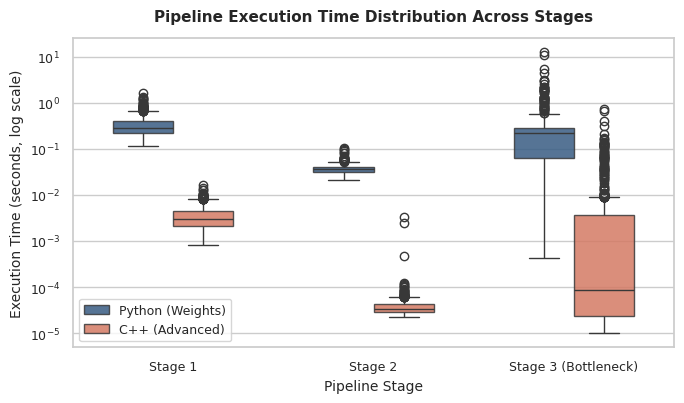

In [21]:
# Combined Multi-Stage Log-Scale Boxplot with Professional Academic Palette
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape the dataframe into a long format using pd.melt
df_melted = pd.melt(
    df_head2head,
    id_vars=['perfil'],
    value_vars=['t_p1', 't_p2', 't_p3'],
    var_name='Stage',
    value_name='Execution Time'
)

# 2. Map stage identifiers to clean, presentation-ready labels
stage_mapping = {
    't_p1': 'Stage 1',
    't_p2': 'Stage 2',
    't_p3': 'Stage 3 (Bottleneck)'
}
df_melted['Stage'] = df_melted['Stage'].map(stage_mapping)

# 3. Professional academic palette: Steel Blue and Warm Coral (Colorblind-friendly & high contrast)
academic_palette = ['#2B5C8F', '#E76F51']

# 4. Create the consolidated figure
fig, ax = plt.subplots(figsize=(7.0, 4.2))

sns.boxplot(
    data=df_melted, 
    x='Stage', 
    y='Execution Time', 
    hue='perfil',
    palette=academic_palette, 
    width=0.6, 
    boxprops=dict(alpha=0.85), 
    ax=ax
)

ax.set_yscale('log')
ax.set_title('Pipeline Execution Time Distribution Across Stages', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Pipeline Stage', fontsize=10)
ax.set_ylabel('Execution Time (seconds, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Legend placed at the lower left in a single column
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=['Python (Weights)', 'C++ (Advanced)'], 
    loc='lower left', 
    ncol=1, 
    fontsize=9, 
    frameon=True
)

plt.tight_layout()
plt.savefig("1_boxplot_velocity_all_stages.pdf", format='pdf', bbox_inches='tight')
plt.show()

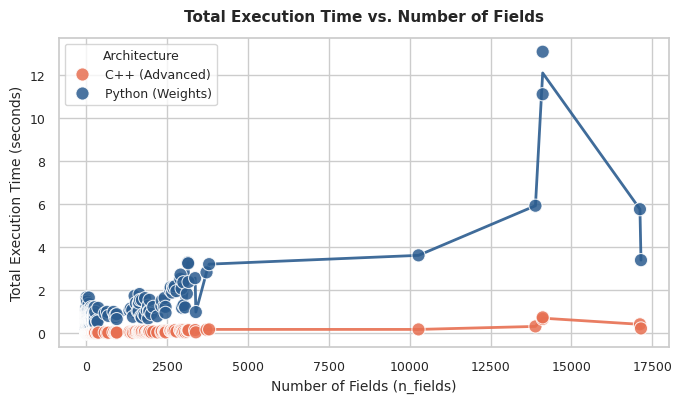

In [22]:
# Cell 6: Standalone Total Execution Time Comparison (Mapped Profiles & Explicit Palette)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordenamos por n_fields y hacemos una copia
df_sorted = df_head2head.sort_values('n_fields').copy()

# 2. Mapeamos los identificadores internos a etiquetas limpias y de publicación
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_sorted['Profile'] = df_sorted['perfil'].map(profile_mapping)

# 3. Configuramos la figura con el tamaño exacto solicitado
fig, ax = plt.subplots(figsize=(7.0, 4.2))

# 4. Diccionario de colores alineado con las etiquetas mapeadas
palette_dict = {
    'Python (Weights)': '#2B5C8F',  # Azul Acero
    'C++ (Advanced)': '#E76F51'     # Coral Cálido
}

# 5. Dibujamos las líneas primero (zorder=1 para que queden de fondo)
sns.lineplot(
    data=df_sorted, x='n_fields', y='total_t', hue='Profile', 
    palette=palette_dict, legend=False, 
    errorbar=None, linewidth=2.0, alpha=0.9, ax=ax, zorder=1
)

# 6. Dibujamos los puntos encima (zorder=2 para que destaquen)
sns.scatterplot(
    data=df_sorted, x='n_fields', y='total_t', hue='Profile', 
    palette=palette_dict, s=90, 
    alpha=0.85, ax=ax, zorder=2
)

ax.set_title('Total Execution Time vs. Number of Fields', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=10)
ax.set_ylabel('Total Execution Time (seconds)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Leyenda limpia y sincronizada
ax.legend(title='Architecture', loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("2_head2head_time_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Espace Analisis

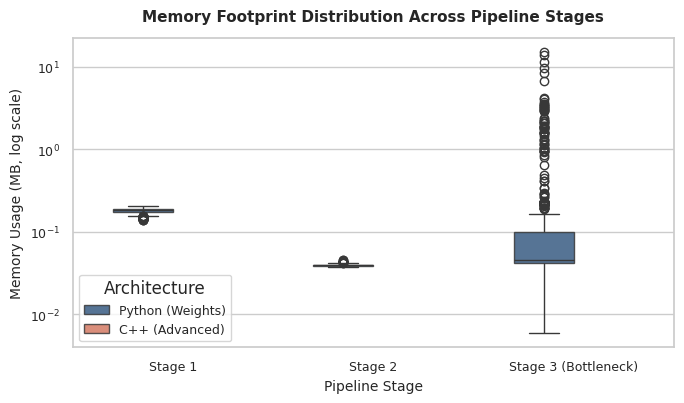

In [23]:
# Combined Multi-Stage Memory Footprint Boxplot using exact schema columns (mem_*_kb)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape the dataframe into a long format using exact memory columns (converted to MB for clarity)
df_memory_melted = pd.melt(
    df_head2head,
    id_vars=['perfil'],
    value_vars=['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb'],
    var_name='Stage',
    value_name='Memory Usage (MB)'
)
df_memory_melted['Memory Usage (MB)'] = df_memory_melted['Memory Usage (MB)'] / 1024.0

# 2. Map stage identifiers to clean, presentation-ready labels
stage_mapping = {
    'mem_p1_kb': 'Stage 1',
    'mem_p2_kb': 'Stage 2',
    'mem_p3_kb': 'Stage 3 (Bottleneck)'
}
df_memory_melted['Stage'] = df_memory_melted['Stage'].map(stage_mapping)

# 3. Explicit profile mapping to match the academic legend
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_memory_melted['Profile'] = df_memory_melted['perfil'].map(profile_mapping).fillna(df_memory_melted['perfil'])

# 4. Professional academic palette: Steel Blue and Warm Coral
academic_palette = ['#2B5C8F', '#E76F51']
profile_order = ['Python (Weights)', 'C++ (Advanced)']

# 5. Create the consolidated figure with strict single-column dimensions
fig, ax = plt.subplots(figsize=(7.0, 4.2))

sns.boxplot(
    data=df_memory_melted, 
    x='Stage', 
    y='Memory Usage (MB)', 
    hue='Profile',
    hue_order=profile_order,
    palette=academic_palette, 
    width=0.6, 
    boxprops=dict(alpha=0.85), 
    ax=ax
)

ax.set_yscale('log')
ax.set_title('Memory Footprint Distribution Across Pipeline Stages', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Pipeline Stage', fontsize=10)
ax.set_ylabel('Memory Usage (MB, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Legend placed at the lower left in a single column
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=profile_order, 
    loc='lower left', 
    ncol=1, 
    fontsize=9, 
    frameon=True,
    title='Architecture'
)

plt.tight_layout()
plt.savefig("3_boxplot_space_stages_log.pdf", format='pdf', bbox_inches='tight')
plt.show()

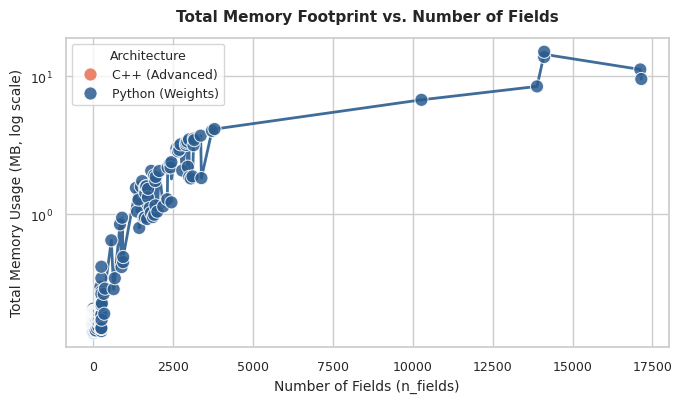

In [24]:
# Cell: Standalone Total Memory Footprint Comparison vs. Number of Fields
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort by n_fields and make a copy
df_sorted = df_head2head.sort_values('n_fields').copy()

# 2. Map internal profiles to publication-ready labels
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_sorted['Profile'] = df_sorted['perfil'].map(profile_mapping)

# 3. Convert total memory from KB to MB for cleaner presentation
df_sorted['mem_total_mb'] = df_sorted['mem_total_kb'] / 1024.0

# 4. Configure figure with precise single-column dimensions
fig, ax = plt.subplots(figsize=(7.0, 4.2))

# 5. Color palette dictionary aligned with mapped profile labels
palette_dict = {
    'Python (Weights)': '#2B5C8F',  # Steel Blue
    'C++ (Advanced)': '#E76F51'     # Warm Coral
}

# 6. Draw lines first (zorder=1 to keep in background)
sns.lineplot(
    data=df_sorted, x='n_fields', y='mem_total_mb', hue='Profile', 
    palette=palette_dict, legend=False, 
    errorbar=None, linewidth=2.0, alpha=0.9, ax=ax, zorder=1
)

# 7. Draw scatter points on top (zorder=2 for visual prominence)
sns.scatterplot(
    data=df_sorted, x='n_fields', y='mem_total_mb', hue='Profile', 
    palette=palette_dict, s=90, 
    alpha=0.85, ax=ax, zorder=2
)

ax.set_yscale('log')
ax.set_title('Total Memory Footprint vs. Number of Fields', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=10)
ax.set_ylabel('Total Memory Usage (MB, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Clean and synchronized legend
ax.legend(title='Architecture', loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("4_head2head_space_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [25]:
# Cell 8: Master Summary Table Generation & Export (Time and Space)
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Extraer perfiles exactos (weights vs cpp_adv)
df_py = df_head2head[df_head2head['perfil'] == 'weights']
df_cpp = df_head2head[df_head2head['perfil'] == 'cpp_adv']

# 2. Computar medianas globales (Tiempo en segundos, Memoria en MB)
py_time = df_py['total_t'].median()
cpp_time = df_cpp['total_t'].median()

py_bot = df_py['t_p3'].median()
cpp_bot = df_cpp['t_p3'].median()

py_mem = df_py['mem_total_kb'].median() / 1024.0
cpp_mem = df_cpp['mem_total_kb'].median() / 1024.0

# 3. Construir la matriz de resultados usando la nomenclatura correcta
summary_data = [
    {
        'Key Metric': 'Overall Execution Time',
        'Python (Weights)': f"{py_time:.4f} s",
        'C++ (Advanced)': f"{cpp_time:.4f} s",
        'Achievement': f"{py_time/cpp_time:.2f}x Speedup"
    },
    {
        'Key Metric': 'Bottleneck Time (Stage 3)',
        'Python (Weights)': f"{py_bot:.4f} s",
        'C++ (Advanced)': f"{cpp_bot:.4f} s",
        'Achievement': f"{py_bot/cpp_bot:.2f}x Speedup"
    },
    {
        'Key Metric': 'Total Memory Footprint',
        'Python (Weights)': f"{py_mem:.2f} MB",
        'C++ (Advanced)': f"{cpp_mem:.2f} MB",
        'Achievement': f"{(1 - cpp_mem/py_mem)*100:.1f}% Reduction"
    }
]

df_summary = pd.DataFrame(summary_data)

# 4. MOSTRAR EN EL NOTEBOOK (Vista renderizada y limpia)
print("=" * 85)
print(" 🏆 MASTER SUMMARY: TIME & SPACE ACHIEVEMENTS")
print("=" * 85)
display(df_summary)
print("=" * 85)

# 5. EXPORTAR A LATEX (Añadiendo formato matemático y negritas)
df_latex = df_summary.copy()
# Reemplazar 'x' por '\times' y '%' por '\%' solo para LaTeX
df_latex['Achievement'] = df_latex['Achievement'].str.replace('x', r'$\times$').str.replace('%', r'\%')
# Poner los nombres de las columnas en negrita
df_latex.columns = [rf'\textbf{{{col}}}' for col in df_latex.columns]

# Actualización del caption para reflejar 'Python (Weights)'
latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format='lllc',
    caption='Summary of primary performance and memory footprint achievements comparing the Python (Weights) implementation against the C++ (Advanced) architecture.',
    label='tab:master_summary'
)

# 6. Guardar siguiendo la nomenclatura estricta
with open("5_summary_table_results.tex", "w") as f:
    f.write(latex_table)

print("✅ Archivo '5_summary_table_results.tex' generado con éxito.")

 🏆 MASTER SUMMARY: TIME & SPACE ACHIEVEMENTS


,Key Metric,Python (Weights),C++ (Advanced),Achievement
0,Overall Execution Time,0.5331 s,0.0043 s,124.61x Speedup
1,Bottleneck Time (Stage 3),0.2159 s,0.0001 s,2482.05x Speedup
2,Total Memory Footprint,0.18 MB,0.00 MB,100.0% Reduction


✅ Archivo '5_summary_table_results.tex' generado con éxito.


In [26]:
# Cell 9: Maximum Values & Worst-Case Scenario Summary
import pandas as pd
from IPython.display import display

# 1. Asegurar la separación correcta de perfiles
df_py = df_head2head[df_head2head['perfil'] == 'weights']
df_cpp = df_head2head[df_head2head['perfil'] == 'cpp_adv']

# 2. Calcular los valores máximos absolutos (Peor de los casos y límite explorado)
py_max_time = df_py['total_t'].max()
cpp_max_time = df_cpp['total_t'].max()

py_max_mem = df_py['mem_total_kb'].max() / 1024.0
cpp_max_mem = df_cpp['mem_total_kb'].max() / 1024.0

py_max_fields = df_py['n_fields'].max()
cpp_max_fields = df_cpp['n_fields'].max()

# 3. Construir la estructura de la tabla
max_data = [
    {
        'Maximum Metric': 'Peak Execution Time',
        'Python (Weights)': f"{py_max_time:.4f} s",
        'C++ (Advanced)': f"{cpp_max_time:.4f} s",
        'Observation': f"{py_max_time/cpp_max_time:.2f}x Speedup at peak"
    },
    {
        'Maximum Metric': 'Peak Memory Footprint',
        'Python (Weights)': f"{py_max_mem:.2f} MB",
        'C++ (Advanced)': f"{cpp_max_mem:.2f} MB",
        'Observation': f"{(1 - cpp_max_mem/py_max_mem)*100:.1f}% Reduction at peak"
    },
    {
        'Maximum Metric': 'Max Attractor Fields Found',
        'Python (Weights)': f"{int(py_max_fields):,}",
        'C++ (Advanced)': f"{int(cpp_max_fields):,}",
        'Observation': "Exact Match (Validates Logic)" if py_max_fields == cpp_max_fields else "Mismatch Check Needed!"
    }
]

df_max = pd.DataFrame(max_data)

# 4. MOSTRAR EN EL NOTEBOOK (Vista renderizada y limpia)
print("=" * 90)
print(" 🚨 WORST-CASE SCENARIO & PEAK DISCOVERIES SUMMARY")
print("=" * 90)
display(df_max)
print("=" * 90)

# 5. EXPORTAR A LATEX (Añadiendo formato matemático y negritas)
df_max_latex = df_max.copy()
# Reemplazar 'x' por '\times' y '%' por '\%' para LaTeX
df_max_latex['Observation'] = df_max_latex['Observation'].str.replace('x', r'$\times$').str.replace('%', r'\%')
# Nombres de las columnas en negrita
df_max_latex.columns = [rf'\textbf{{{col}}}' for col in df_max_latex.columns]

# Generar la tabla con el caption ajustado
latex_max_table = df_max_latex.to_latex(
    index=False,
    escape=False,
    column_format='lllc',
    caption='Summary of absolute maximum observed values (worst-case execution time and memory footprint) and peak attractor fields discovered, comparing Python (Weights) and C++ (Advanced).',
    label='tab:max_values'
)

# 6. Guardar siguiendo la nomenclatura estricta del experimento
with open("6_max_values_table.tex", "w") as f:
    f.write(latex_max_table)

print("✅ Archivo '6_max_values_table.tex' generado con éxito.")

 🚨 WORST-CASE SCENARIO & PEAK DISCOVERIES SUMMARY


,Maximum Metric,Python (Weights),C++ (Advanced),Observation
0,Peak Execution Time,13.0939 s,0.7299 s,17.94x Speedup at peak
1,Peak Memory Footprint,15.10 MB,0.00 MB,100.0% Reduction at peak
2,Max Attractor Fields Found,"17,152","17,152",Exact Match (Validates Logic)


✅ Archivo '6_max_values_table.tex' generado con éxito.
